In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("../Data/Train.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [3]:
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64


In [5]:
X = df[['Cost_of_the_Product', 'Weight_in_gms']]

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

In [8]:
print("Cluster Centers:\n", kmeans.cluster_centers_)

Cluster Centers:
 [[-0.17723165  0.78610246]
 [ 0.96278799 -0.91798321]
 [-1.10436051 -1.15312397]]


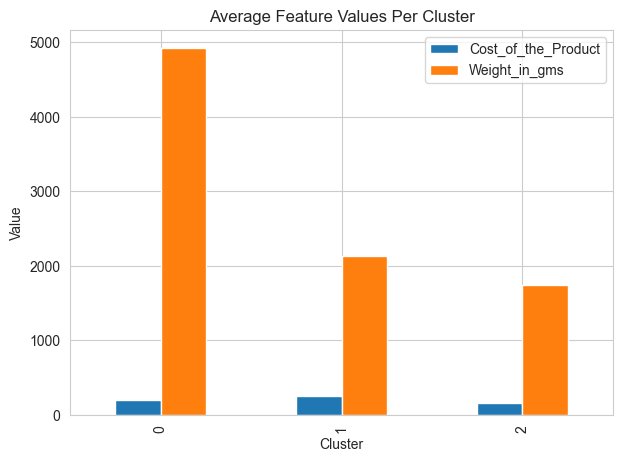

In [15]:
cluster_summary = df.groupby('Cluster')[['Cost_of_the_Product','Weight_in_gms']].mean()

cluster_summary.plot(kind='bar', figsize=(7,5))

plt.title("Average Feature Values Per Cluster")
plt.ylabel("Value")
plt.xlabel("Cluster")

plt.show()

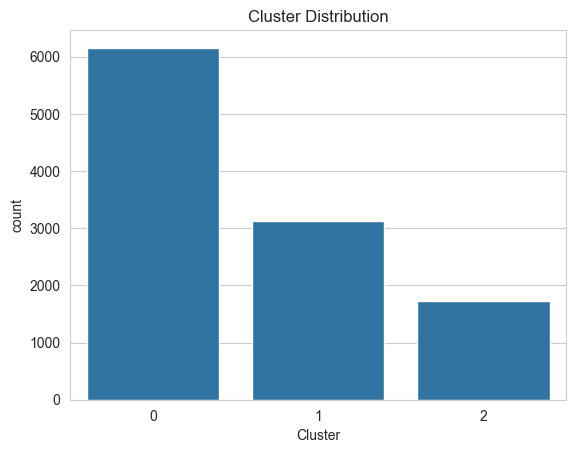

In [10]:
sns.countplot(x=df['Cluster'])

plt.title("Cluster Distribution")
plt.show()

In [11]:
X_features = df.drop(['Reached.on.Time_Y.N'], axis=1)
y = df['Reached.on.Time_Y.N']

X_features = pd.get_dummies(X_features, drop_first=True)

selector = SelectKBest(score_func=f_classif, k=5)

X_new = selector.fit_transform(X_features, y)

selected_features = X_features.columns[selector.get_support()]

print("Top 5 Features:")
print(selected_features)

Top 5 Features:
Index(['ID', 'Cost_of_the_Product', 'Discount_offered', 'Weight_in_gms',
       'Cluster'],
      dtype='str')
